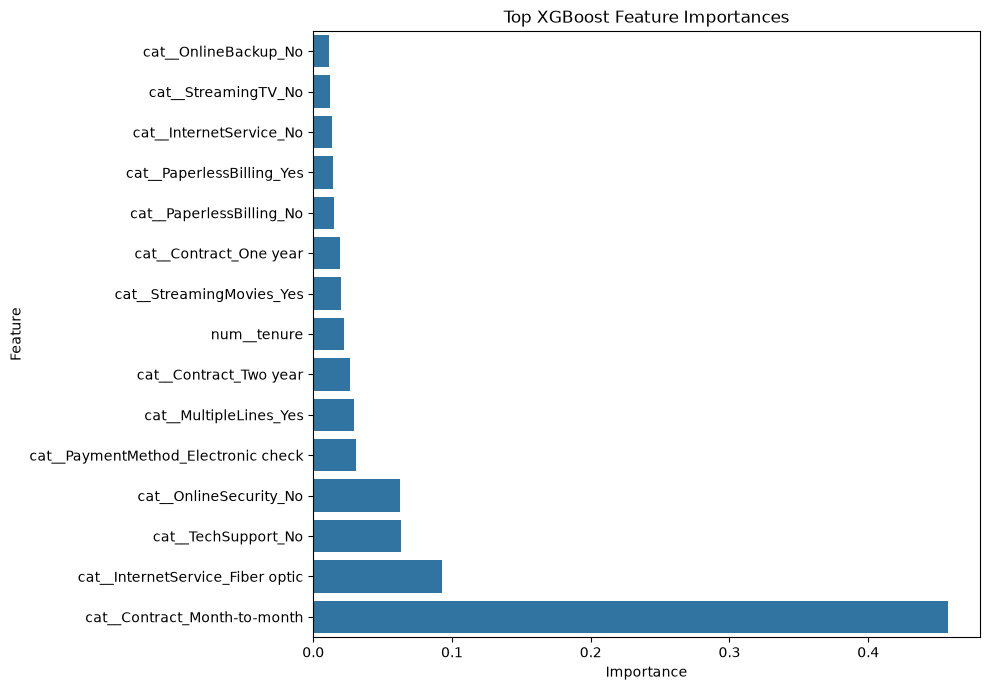

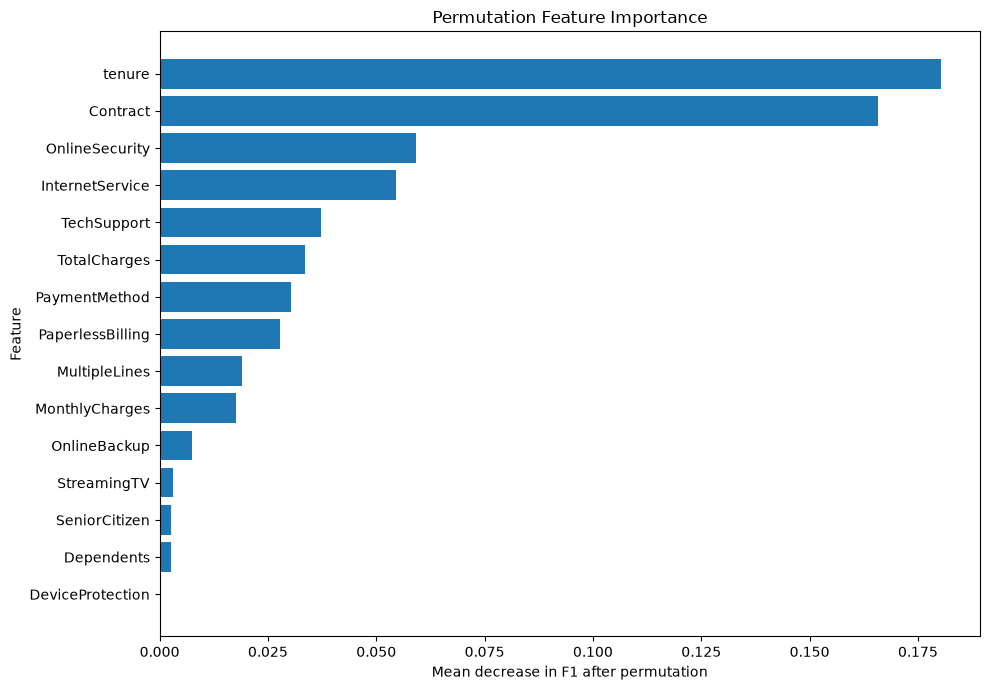

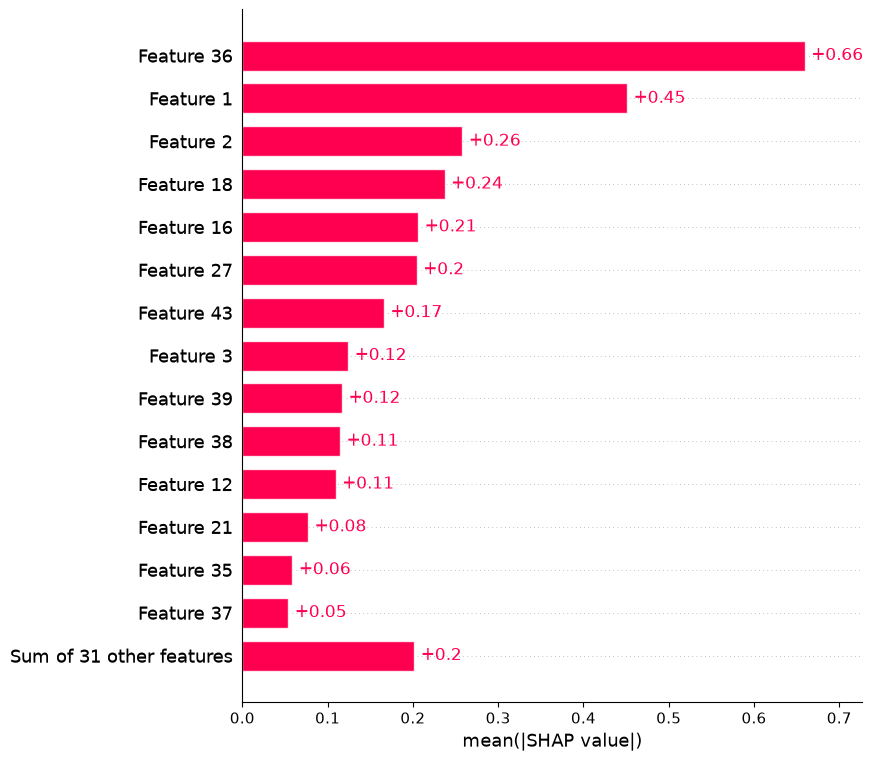

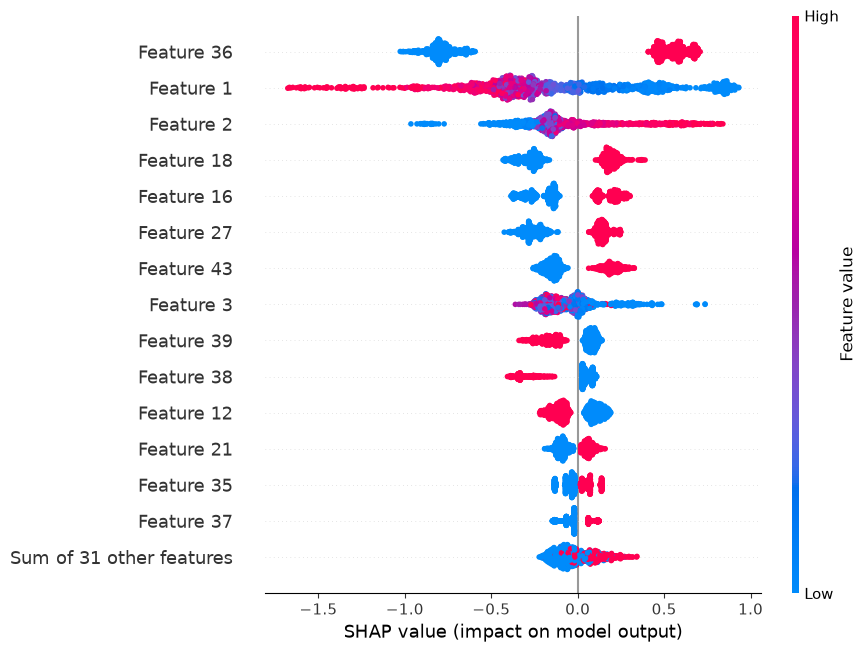

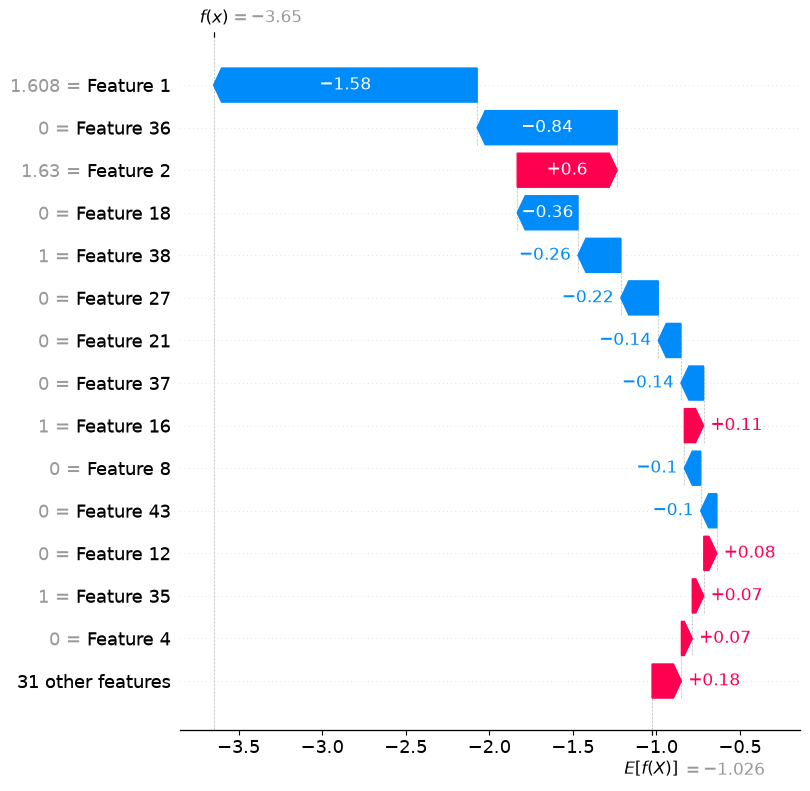

In [ ]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

best_logistic = joblib.load(
    "../models/logistic_regression_tuned.joblib"
)

best_rf = joblib.load(
    "../models/random_forest_tuned.joblib"
)

best_xgb = joblib.load(
    "../models/xgboost_tuned.joblib"
)
model = best_xgb

xgb_classifier = model.named_steps["classifier"]

preprocessor = model.named_steps["preprocessor"]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = (
    xgb_classifier
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance_df.head(20)

top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top XGBoost Feature Importances"
)

plt.tight_layout()
plt.show()

from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
})

perm_df = perm_df.sort_values(
    "Importance_Mean",
    ascending=False
)

perm_df.head(15)

top_perm = (
    perm_df
    .head(15)
    .sort_values(
        "Importance_Mean"
    )
)
plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance_Mean"]
)

plt.xlabel(
    "Mean decrease in F1 after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance"
)

plt.tight_layout()
plt.show()

X_test_transformed = (
    preprocessor.transform(X_test)
)
feature_names = (
    preprocessor
    .get_feature_names_out()
)
explainer = shap.TreeExplainer(
    xgb_classifier
)
shap_values = explainer(
    X_test_transformed
)

shap.plots.bar(
    shap_values,
    max_display=15
)

shap.plots.beeswarm(
    shap_values,
    max_display=15
)

customer_index = 0
customer = X_test_transformed[
    customer_index
]

shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15
)
shap.plots.scatter(
    shap_values[:, "num__tenure"]
)
list(feature_names)
explainability_summary = pd.DataFrame({
    "Native Importance": feature_importance_df
        .set_index("Feature")["Importance"],

})
def generate_basic_explanation(
    customer,
    probability
):
    explanation = {
        "churn_probability": float(probability),
        "risk_level": (
            "High"
            if probability >= 0.70
            else "Medium"
            if probability >= 0.40
            else "Low"
        )
    }

    return explanation


